# Hopfield Network & Associative Memory

## What is a Hopfield Network?

A **Hopfield network** is a recurrent neural network introduced by John Hopfield (1982) that functions as an **associative memory**: it stores patterns and retrieves them from partial or noisy queries. The network dynamics converge to stable fixed points (stored memories).

## Architecture

Each neuron $i$ has a binary state $\sigma_i \in \{-1, +1\}$. Neurons are connected by symmetric weights $W_{ij} = W_{ji}$ (no self-loops: $W_{ii} = 0$). The network stores $p$ patterns $\{\xi^\mu\}_{\mu=1}^p$ via the **Hebbian learning rule**:
$$W_{ij} = \frac{1}{N} \sum_{\mu=1}^p \xi_i^\mu \xi_j^\mu$$

## Energy Function

The Hopfield network has a **Lyapunov energy**:
$$E(\sigma) = -\frac{1}{2} \sum_{i \neq j} W_{ij} \sigma_i \sigma_j$$

Each asynchronous update $\sigma_i \leftarrow \text{sign}\left(\sum_j W_{ij} \sigma_j\right)$ monotonically decreases $E$, guaranteeing convergence to a local minimum.

## 2D Cellular Version

We study a **spatial Hopfield model** on a 2D grid of $n \times n$ binary spins. Each spin interacts with its four nearest neighbors. This is closely related to the **Ising model** in statistical physics:
$$E = -J \sum_{\langle i,j\rangle} \sigma_i \sigma_j$$

The dynamics minimize energy by flipping spins whose local field $h_i = J(\sigma_{i-1} + \sigma_{i+1} + \sigma_{i,j-1} + \sigma_{i,j+1})$ disagrees with the current spin state.

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, Play, HBox, VBox
import ipywidgets as widgets

### Nearest-neighbor spin update

For the 2D spatial model, the local field at spin $(i,j)$ is the sum of its four neighbors (periodic boundary):
$$h_{ij} = W_1 \sigma_{i+1,j} + W_2 \sigma_{i-1,j} + W_3 \sigma_{i,j+1} + W_4 \sigma_{i,j-1}$$

We update a random batch of $p$ spins per iteration using the rule $\sigma_{ij} \leftarrow \text{sign}(h_{ij})$.

In [2]:
def local_field(S):
    """Compute local field = sum of 4 nearest neighbors (periodic BC)."""
    return (np.roll(S, 1, axis=0) + np.roll(S, -1, axis=0) +
            np.roll(S, 1, axis=1) + np.roll(S, -1, axis=1))

def energy_per_spin(S):
    """Mean energy per spin: E = -J * sum_{neighbors} sigma_i sigma_j / N."""
    H = local_field(S)
    return -0.5 * np.mean(S * H)

def update_spins(S, p_flip=3000, rng=None):
    """Randomly update p_flip spins toward reducing energy."""
    if rng is None:
        rng = np.random.default_rng()
    H = local_field(S)
    # All spins that disagree with their field
    candidates = np.where((S * H < 0).ravel())[0]
    if len(candidates) == 0:
        return S
    n_flip = min(p_flip, len(candidates))
    chosen = rng.choice(candidates, n_flip, replace=False)
    S_new = S.copy()
    rows, cols = np.unravel_index(chosen, S.shape)
    S_new[rows, cols] = np.sign(H.ravel()[chosen])
    return S_new

### Dynamics from a random initial state

Starting from a uniformly random spin configuration $\sigma \in \{-1,+1\}^{n \times n}$, we run the local energy-descent update. The system converges toward a ferromagnetic state (all spins aligned) or an anti-ferromagnetic checkerboard pattern depending on initial conditions.

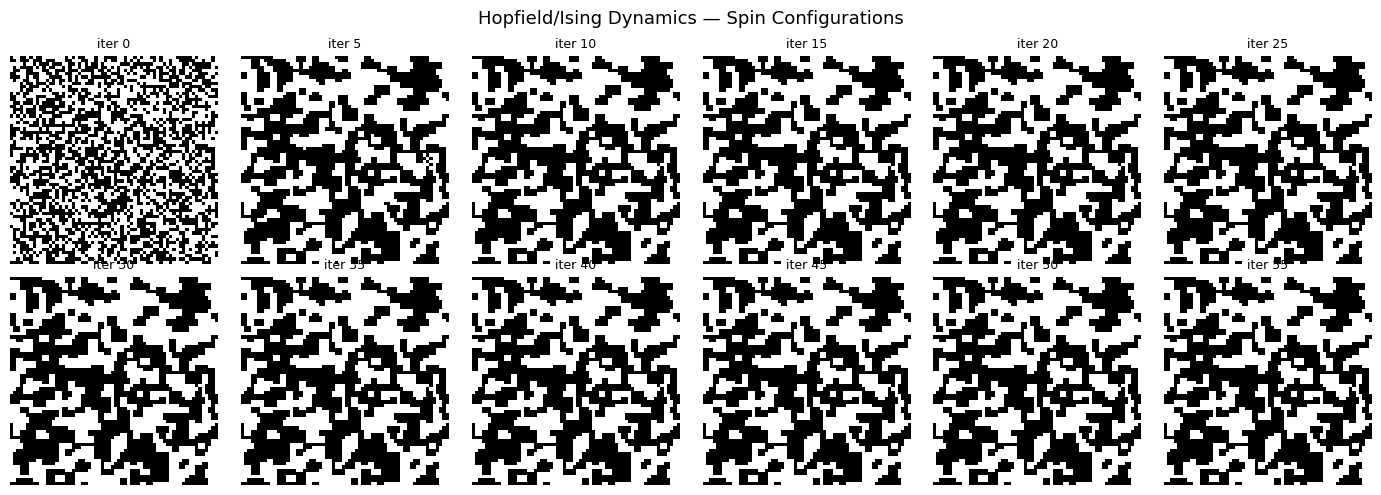

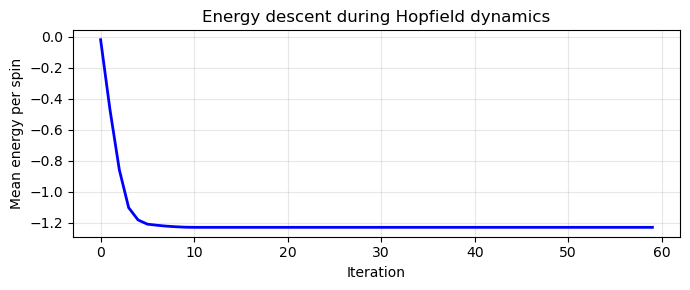

In [3]:
n = 64
rng = np.random.default_rng(42)
S0 = rng.choice([-1, 1], size=(n, n)).astype(float)

n_iter = 60
snapshots = []
energies = []
S = S0.copy()
for it in range(n_iter):
    if it % 5 == 0:
        snapshots.append(S.copy())
    energies.append(energy_per_spin(S))
    S = update_spins(S, p_flip=500, rng=rng)

# Show snapshots
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i, (ax, snap) in enumerate(zip(axes.ravel(), snapshots)):
    ax.imshow(snap, cmap='gray', vmin=-1, vmax=1)
    ax.set_title(f'iter {5*i}', fontsize=9)
    ax.axis('off')
plt.suptitle('Hopfield/Ising Dynamics — Spin Configurations', fontsize=13)
plt.tight_layout(); plt.savefig('hopfield_snap.png', dpi=100, bbox_inches='tight'); plt.show()

plt.figure(figsize=(7, 3))
plt.plot(energies, 'b-', lw=2)
plt.xlabel('Iteration'); plt.ylabel('Mean energy per spin')
plt.title('Energy descent during Hopfield dynamics')
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('hopfield_energy.png', dpi=100, bbox_inches='tight'); plt.show()

### Associative memory: storing and retrieving patterns

Now we store $p$ random binary patterns $\xi^\mu \in \{-1,+1\}^N$ using the Hebbian weight matrix $W = \frac{1}{N} \sum_\mu \xi^\mu (\xi^\mu)^T$. The network retrieves a stored pattern from a noisy initial state.

**Retrieval quality** is measured by the **overlap** (normalized correlation):
$$m^\mu = \frac{1}{N} \sum_i \xi_i^\mu \sigma_i \in [-1, 1]$$

A value $m^\mu \approx 1$ means perfect recall of pattern $\mu$.

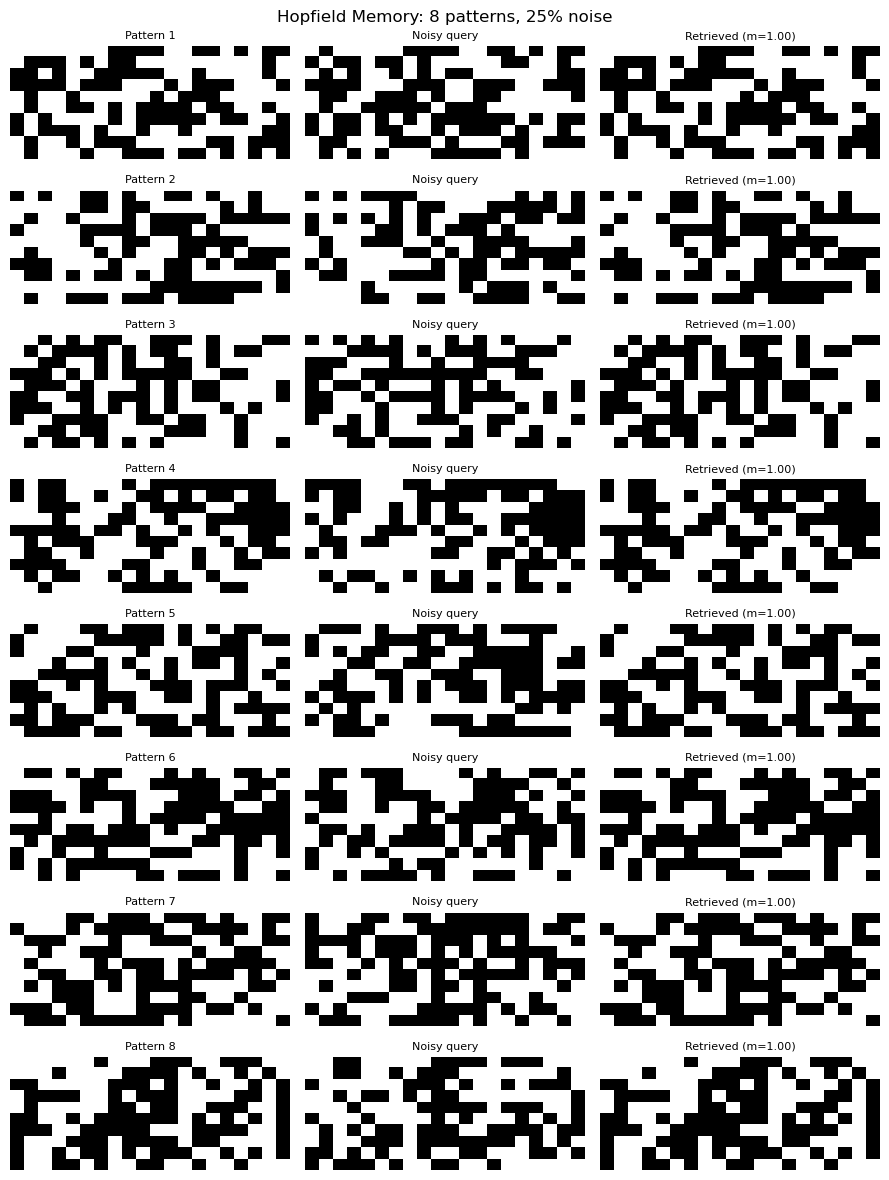

In [4]:
N = 200        # neurons
p_store = 8    # stored patterns
noise_level = 0.25  # fraction of bits to flip

rng2 = np.random.default_rng(7)
patterns = rng2.choice([-1, 1], size=(p_store, N)).astype(float)

# Hebbian weight matrix
W = (patterns.T @ patterns) / N
np.fill_diagonal(W, 0)

def hopfield_dynamics(sigma, W, n_iter=20):
    """Asynchronous update: cycle through all neurons."""
    sigma = sigma.copy()
    for _ in range(n_iter):
        for i in np.random.permutation(len(sigma)):
            sigma[i] = np.sign(W[i] @ sigma)
    return sigma

# Test retrieval for each pattern
fig, axes = plt.subplots(p_store, 3, figsize=(9, 12))
for mu in range(p_store):
    pat = patterns[mu]
    # Noisy query
    flip = rng2.random(N) < noise_level
    query = pat.copy(); query[flip] *= -1
    # Retrieve
    retrieved = hopfield_dynamics(query, W, n_iter=10)
    overlap = (pat @ retrieved) / N

    for ax, sig, title in zip(axes[mu], [pat, query, retrieved],
                               [f'Pattern {mu+1}', 'Noisy query', f'Retrieved (m={overlap:.2f})']):
        ax.imshow(sig.reshape(10,20), cmap='gray', vmin=-1, vmax=1, aspect='auto')
        ax.set_title(title, fontsize=8); ax.axis('off')

plt.suptitle(f'Hopfield Memory: {p_store} patterns, {int(100*noise_level)}% noise', fontsize=12)
plt.tight_layout(); plt.savefig('hopfield_memory.png', dpi=100, bbox_inches='tight'); plt.show()

### Storage capacity

The Hopfield network can reliably store approximately $0.138N$ patterns before retrieval quality degrades. We plot the mean overlap as a function of the number of stored patterns $p$, for $N = 200$.

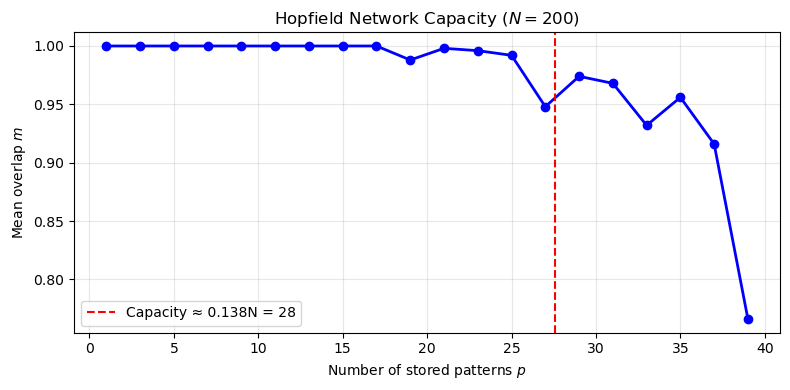

In [5]:
N_cap = 200
p_list = list(range(1, 40, 2))
n_trials = 5
mean_overlaps = []

rng3 = np.random.default_rng(99)
for p_test in p_list:
    pats = rng3.choice([-1, 1], size=(p_test, N_cap)).astype(float)
    W_t = (pats.T @ pats) / N_cap
    np.fill_diagonal(W_t, 0)
    overlaps = []
    for trial in range(n_trials):
        mu = rng3.integers(0, p_test)
        flip = rng3.random(N_cap) < 0.1
        q = pats[mu].copy(); q[flip] *= -1
        ret = hopfield_dynamics(q, W_t, n_iter=5)
        overlaps.append(abs((pats[mu] @ ret) / N_cap))
    mean_overlaps.append(np.mean(overlaps))

plt.figure(figsize=(8, 4))
plt.plot(p_list, mean_overlaps, 'o-b', lw=2)
plt.axvline(0.138 * N_cap, color='r', linestyle='--', label=f'Capacity ≈ 0.138N = {0.138*N_cap:.0f}')
plt.xlabel('Number of stored patterns $p$')
plt.ylabel('Mean overlap $m$')
plt.title(f'Hopfield Network Capacity ($N={N_cap}$)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('hopfield_capacity.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: 2D spin dynamics

Use the slider to step through the Hopfield/Ising dynamics frame by frame.

In [ ]:
# Pre-compute more snapshots for smooth playback
n_snap = 30
rng4 = np.random.default_rng(55)
S_anim = rng4.choice([-1,1], size=(n,n)).astype(float)
anim_snaps = [S_anim.copy()]
for _ in range(n_snap - 1):
    S_anim = update_spins(S_anim, p_flip=300, rng=rng4)
    anim_snaps.append(S_anim.copy())

def show_frame(frame=0):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(anim_snaps[frame], cmap='gray', vmin=-1, vmax=1)
    ax.set_title(f'Iteration {frame}  |  Energy = {energy_per_spin(anim_snaps[frame]):.4f}')
    ax.axis('off'); plt.tight_layout(); plt.show()

interact(show_frame, frame=IntSlider(min=0, max=n_snap-1, step=1, value=0));

### Snippet

In [6]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt
    fig, axes = _plt.subplots(2, 6, figsize=(12, 4))
    for i, (ax, snap) in enumerate(zip(axes.ravel(), snapshots)):
        ax.imshow(snap, cmap='gray', vmin=-1, vmax=1)
        ax.set_title(f'it {5*i}', fontsize=9); ax.axis('off')
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- A Hopfield network is an energy-based model whose fixed points are stored memories.
- The Hebbian learning rule $W = \frac{1}{N} \Xi \Xi^T$ encodes patterns as local energy minima.
- The storage capacity is approximately $0.138N$ patterns — above this, spurious attractors appear.
- The spatial 2D version is equivalent to the **Ising model**, converging to ferromagnetic domains.

## Bibliography

- J. J. Hopfield, *Neural networks and physical systems with emergent collective computational abilities*, PNAS, 1982.
- D. J. Amit, *Modeling Brain Function*, Cambridge UP, 1989.
- H. Ramsauer et al., *Hopfield Networks is All You Need*, ICLR 2021.